In [491]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)


# Cluster Analysis

To conduct a clustering of the registered users, we first need to extract all session with a registered user and store these instances in a new variable

In [492]:
registered_users_df = merged_df[merged_df['isRegisteredUser'] == True].copy()

In [493]:
print(f"Total sessions in merged_df: {len(merged_df)}")
print(f"Sessions from registered users: {len(registered_users_df)}")
print(f"Unique registered users to cluster: {registered_users_df['userID'].nunique()}")

Total sessions in merged_df: 65006
Sessions from registered users: 47815
Unique registered users to cluster: 1006


In [494]:
registered_users_df['siteID'].dtype
registered_users_df['siteID_numeric'] = (registered_users_df['siteID'] == '1').astype(int)

In [495]:
registered_users_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47815 entries, 2 to 65005
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   id                  47815 non-null  object                             
 1   connectionTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 2   disconnectTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 3   doneChargingTime    47815 non-null  datetime64[ns, America/Los_Angeles]
 4   kWhDelivered        47815 non-null  float64                            
 5   sessionID           47815 non-null  object                             
 6   siteID              47815 non-null  object                             
 7   spaceID             47815 non-null  object                             
 8   stationID           47815 non-null  object                             
 9   userID              47815 non-null  object  

In [496]:
# Aggregating statisitcs to User Level
user_profiles = registered_users_df.groupby('userID').agg(
    avg_energy=('kWhDelivered', 'mean'),
    std_energy=('kWhDelivered', 'std'),
    total_energy=('kWhDelivered', 'sum'),
    avg_kWh_req=('kWhRequested', 'mean'),
    frequency=('sessionID', 'count'),
    avg_duration=('session_duration', 'mean'),
    total_charging_duration=('charging_duration', 'sum'),
    avg_charging_duration=('charging_duration', 'mean'), 
    avg_start_hour=('hour', 'mean'),
    pct_weekend_sessions=('is_weekend', 'mean'),
    avg_minutes_available=('minutesAvailable', 'mean'),
    pct_site_1=('siteID_numeric', 'mean')
)

user_profiles['avg_energy_per_session'] = user_profiles['total_energy'] / user_profiles['frequency']
user_profiles['avg_charging_speed'] = user_profiles['total_energy'] / (user_profiles['total_charging_duration'] / 60)



In [497]:
user_profiles.head()

,avg_energy,std_energy,total_energy,avg_kWh_req,frequency,avg_duration,total_charging_duration,avg_charging_duration,avg_start_hour,pct_weekend_sessions,avg_minutes_available,pct_site_1,avg_energy_per_session,avg_charging_speed
userID,,,,,,,,,,,,,,
1.0,1.659000,NaN,1.659000,5.000000,1,1.404444,1.241111,1.241111,13.000000,0.0,150.000000,0.0,1.659000,80.202328
17.0,1.471000,NaN,1.471000,13.840000,1,0.302222,0.300278,0.300278,15.000000,1.0,72.000000,0.0,1.471000,293.927845
22.0,18.754998,8.609281,1087.789899,36.906034,58,6.354296,245.049722,4.224995,9.396552,0.0,462.034483,0.0,18.754998,266.343472
43.0,43.266000,NaN,43.266000,43.400000,1,8.282222,6.988333,6.988333,9.000000,1.0,469.000000,0.0,43.266000,371.470546
45.0,8.069000,NaN,8.069000,17.500000,1,3.551389,2.157500,2.157500,17.000000,1.0,134.000000,0.0,8.069000,224.398610


In [498]:
# use a indicator fo user with only one session & fill std_energy NaN with median
user_profiles['single_session_user'] = (user_profiles['frequency'] == 1).astype(int)
std_median = user_profiles['std_energy'].median(skipna=True)
user_profiles['std_energy_filled'] = user_profiles['std_energy'].fillna(std_median)

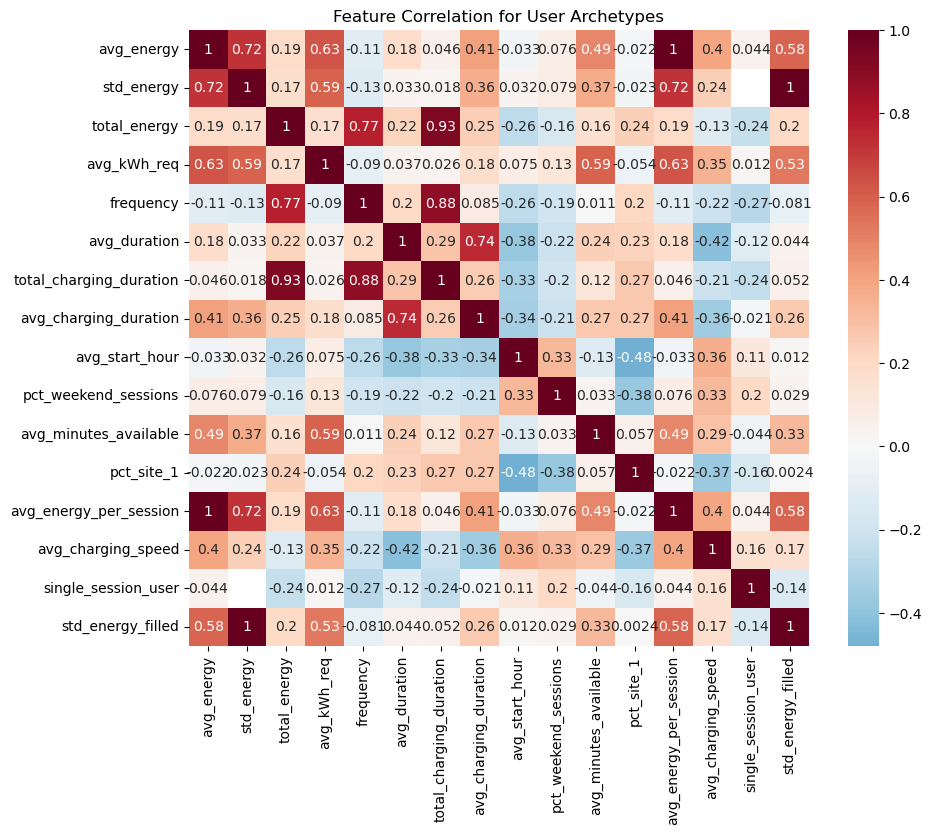

In [499]:
corr_matrix = user_profiles.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation for User Archetypes')
plt.show()

We use a correlation matrix to identify redundant features before clustering. If two features are highly correlated —such as `avg_session_duration` and `avg_charging_duration` (0.74)— including both would effectively double their weight in the distance calculation, biasing the clusters.

The matrix also reveals unexpected relationships between variables. For instance, while we would intuitively expect a strong positive correlation between `avg_duration` and `avg_energy`, they show a surprisingly low correlation of only 0.18. This suggests that stay time is not a reliable predictor of energy delivered, indicating distinct user behaviors, which we will explore further in the following analysis.

In [500]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

features_to_standardize = ['std_energy_filled',
    'frequency','avg_duration',
     'avg_start_hour',
      'avg_charging_speed']
features_to_passthrough = [] # if we want to include features such as 'pct_site_1' without scaling
cluster_features = features_to_standardize + features_to_passthrough

ct = ColumnTransformer([
    ('scaled_features', StandardScaler(), features_to_standardize),
    ('passthrough_features', 'passthrough', features_to_passthrough)
])

user_profiles_scaled_array = ct.fit_transform(user_profiles)

user_profiles_scaled = pd.DataFrame(
    user_profiles_scaled_array,
    columns=cluster_features,
    index=user_profiles.index
)

We chose to limit the clustering analysis on fewer features for the following reasons:
* Including more features led to overlap between groups, making it difficult to identify distinct clusters.
* The resulting archetypes are easier to define and understand.

We chose `avg_duration` and `avg_energy` because despite the expectation that energy consumption would increase with session duration, these features showed a low correlation of only 0.18. This low correlation indicates the existence of two very different behaviors: users who treat the station primarily for parking (high duration, low energy) and those who use it for efficient charging (high energy, relatively lower duration). Our aim is to confirm these groups through clustering.

We choose the following features to cover many different dimension which gives us better interpreting clusters.

* Energy and Demand
  * avg_energy
  * (avg_kWh_req)
  * std_energy
* Frequency and duration of use
  * frequency
  * avg_duration
  * (avg_charging_duration)
* Temporal Behavior
  * avg_start_hour
  * pct_weekend_sessions
* Availability and Location
  * (avg_minutes_available)
  * pct_site_1
* Charging Behavior/ Efficiency
  * avg_charging_speed



In [501]:
print(user_profiles_scaled.shape)

(1006, 5)


In [502]:

outliers = (np.abs(user_profiles_scaled[[ 'std_energy_filled',
    'frequency','avg_duration',
    'avg_start_hour',
    
    'avg_charging_speed']]) > 3).any(axis=1)
print(f"Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 3): {outliers.sum()}")

Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 3): 94


The features `avg_duration` and `avg_energy` contain outliers that could negatively impact the clustering process. To address this we, identify and remove outliers using the 1 sigma threshold, which has proven to improve the Silhouette Score later the best.

In [503]:
user_profiles_scaled = user_profiles_scaled[~outliers].copy()
user_profiles = user_profiles[~outliers].copy()

### Hyperparameter Tuning

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\clust

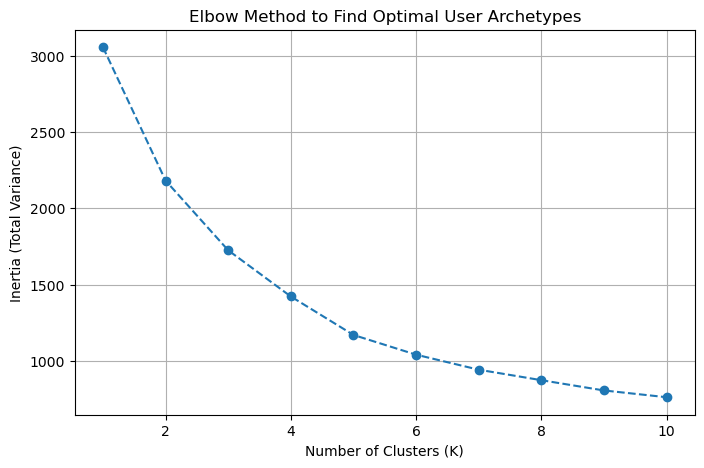

In [504]:
from sklearn.cluster import KMeans

# Calculate inertia for K=1 to K=10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(user_profiles_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Total Variance)')
plt.title('Elbow Method to Find Optimal User Archetypes')
plt.grid(True)
plt.show()

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\clust

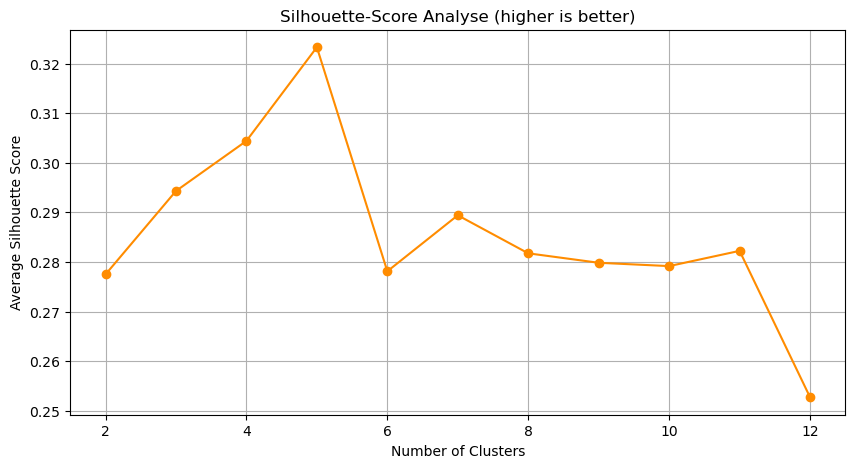

In [505]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
range_n_clusters = [2, 3, 4, 5, 6, 7, 8 ,9 ,10, 11, 12]
silhouette_avgs = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(user_profiles_scaled)
    
    silhouette_avg = silhouette_score(user_profiles_scaled, cluster_labels)
    silhouette_avgs.append(silhouette_avg)
    # print(f"Für n_clusters = {n_clusters} ist der durchschnittliche Silhouette-Score: {silhouette_avg:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avgs, marker='o', color='darkorange')
plt.title('Silhouette-Score Analyse (higher is better)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

We decided to use 4 clusters for our analysis because:
* The Silhouette analysis shows a clear peak at $k=4$ with a score of approximately 0.435. This indicates that four clusters provide the best balance between internal cohesion and separation between groups.
* In the Elbow plot, the "bend" or elbow occurs at $k=4$. Adding a fifth cluster results in significantly diminishing returns in terms of reducing the Total Variance (Inertia), suggesting that four is the "sweet spot" for capturing the data's underlying structure.

### Cluster Alg implementation

In [506]:

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=8, 
    init='k-means++', 
    n_init=10, 
    random_state=42
)
kmeans.fit(user_profiles_scaled)

user_profiles['Clusters'] = kmeans.predict(user_profiles_scaled)


c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


#### I decided to choose KMeans, however this is GMM implementation.

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\clust

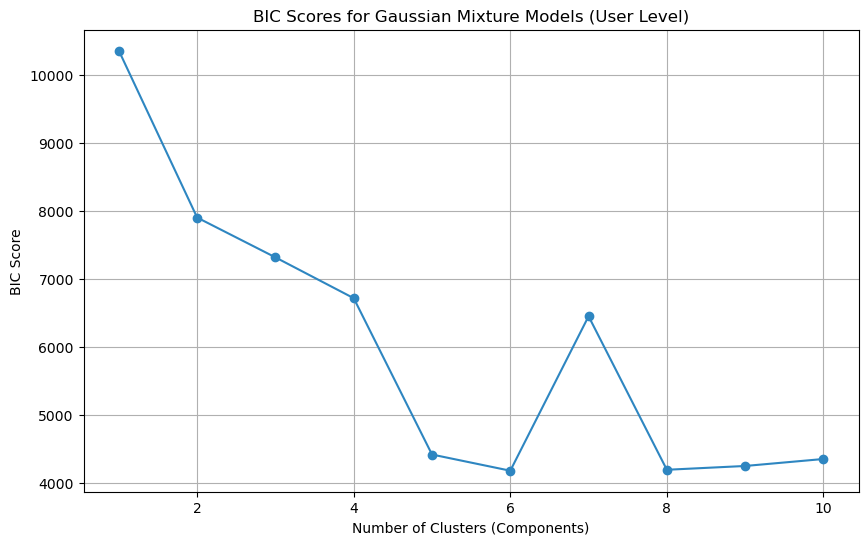

In [507]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. BIC-Score Berechnung zur Bestimmung der optimalen Cluster-Anzahl
bic_scores = []
n_components_range = range(1, 11)  # Bei 1000 Usern reichen oft 1-10 Komponenten

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(user_profiles_scaled)
    bic_scores.append(gmm.bic(user_profiles_scaled))

# Plot BIC
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o', color='#2E86C1')
plt.title('BIC Scores for Gaussian Mixture Models (User Level)')
plt.xlabel('Number of Clusters (Components)')
plt.ylabel('BIC Score')
plt.grid(True)
plt.show()

In [508]:
optimal_components = 5
best_gmm = GaussianMixture(n_components=optimal_components)
best_gmm.fit(user_profiles_scaled)
user_profiles['Clusters'] = best_gmm.predict(user_profiles_scaled)

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


### Clustering Results Analysis

In [509]:
cluster_mapping = {
    0: 'Cluster 1', 
    1: 'Cluster 2',
    2: 'Cluster 3',
    3: 'Cluster 4',
    4: 'Cluster 5'
   
    
}
user_profiles['Clusters_Name'] = user_profiles['Clusters'].map(cluster_mapping)

cluster_summary = user_profiles.groupby('Clusters_Name')[cluster_features].mean()

print("--- ARCHETYPEN REPORT (Mean per cluster) ---")

print(cluster_summary.T) 

print("\nNumber of users per archetype:")
counts = user_profiles['Clusters_Name'].value_counts()
print(counts)

--- ARCHETYPEN REPORT (Mean per cluster) ---
Clusters_Name         Cluster 1   Cluster 2   Cluster 3   Cluster 4  \
std_energy_filled      6.169211    3.450991   10.376628    3.502108   
frequency             12.728395    3.124528   17.608974   56.200000   
avg_duration           1.059983    4.068570    5.222988    9.455662   
avg_start_hour        14.584004   11.696491   11.124985   14.047423   
avg_charging_speed  1260.110833  247.042010  310.136302  253.208352   

Clusters_Name        Cluster 5  
std_energy_filled     4.959405  
frequency            86.826667  
avg_duration          6.631949  
avg_start_hour        9.292123  
avg_charging_speed  192.752321  

Number of users per archetype:
Clusters_Name
Cluster 5    375
Cluster 2    265
Cluster 3    156
Cluster 1     81
Cluster 4     35
Name: count, dtype: int64


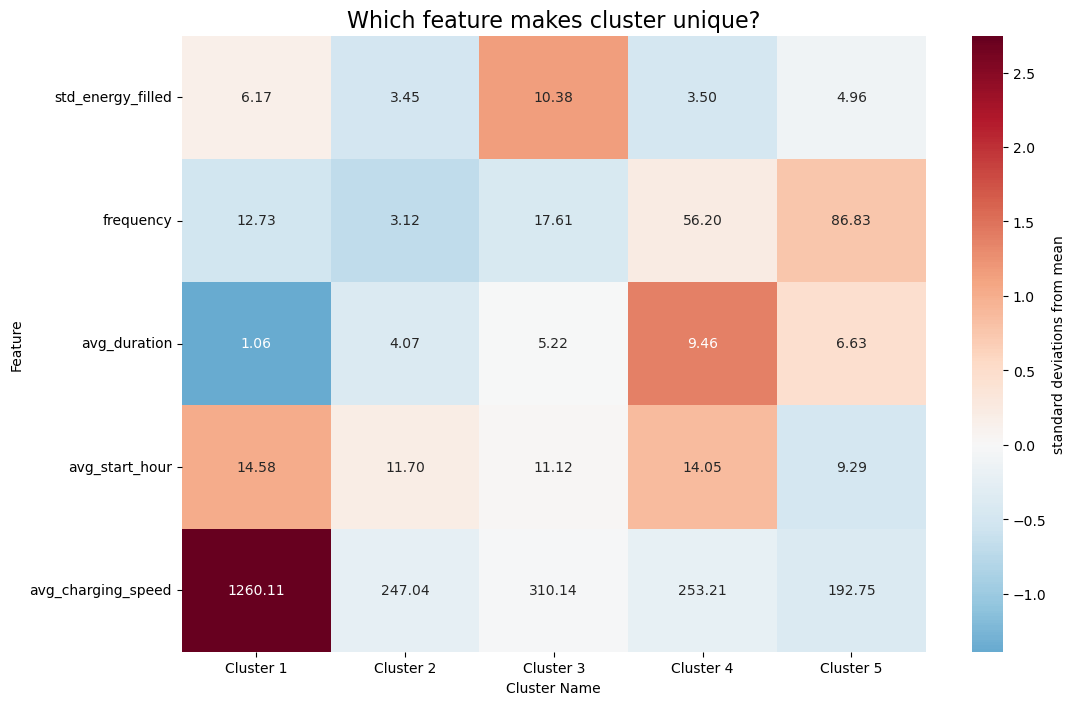

In [510]:
import seaborn as sns

cluster_summary = user_profiles.groupby('Clusters_Name')[cluster_features].mean()

# (Z-Score der Mittelwerte)
summary_scaled = (cluster_summary - user_profiles[cluster_features].mean()) / user_profiles[cluster_features].std()

plt.figure(figsize=(12, 8))
sns.heatmap(summary_scaled.T, 
            annot=cluster_summary.T,
            fmt=".2f", 
            cmap="RdBu_r", 
            center=0,
            cbar_kws={'label': 'standard deviations from mean'})

plt.title('Which feature makes cluster unique?', fontsize=16)
plt.xlabel('Cluster Name')
plt.ylabel('Feature')
plt.show()

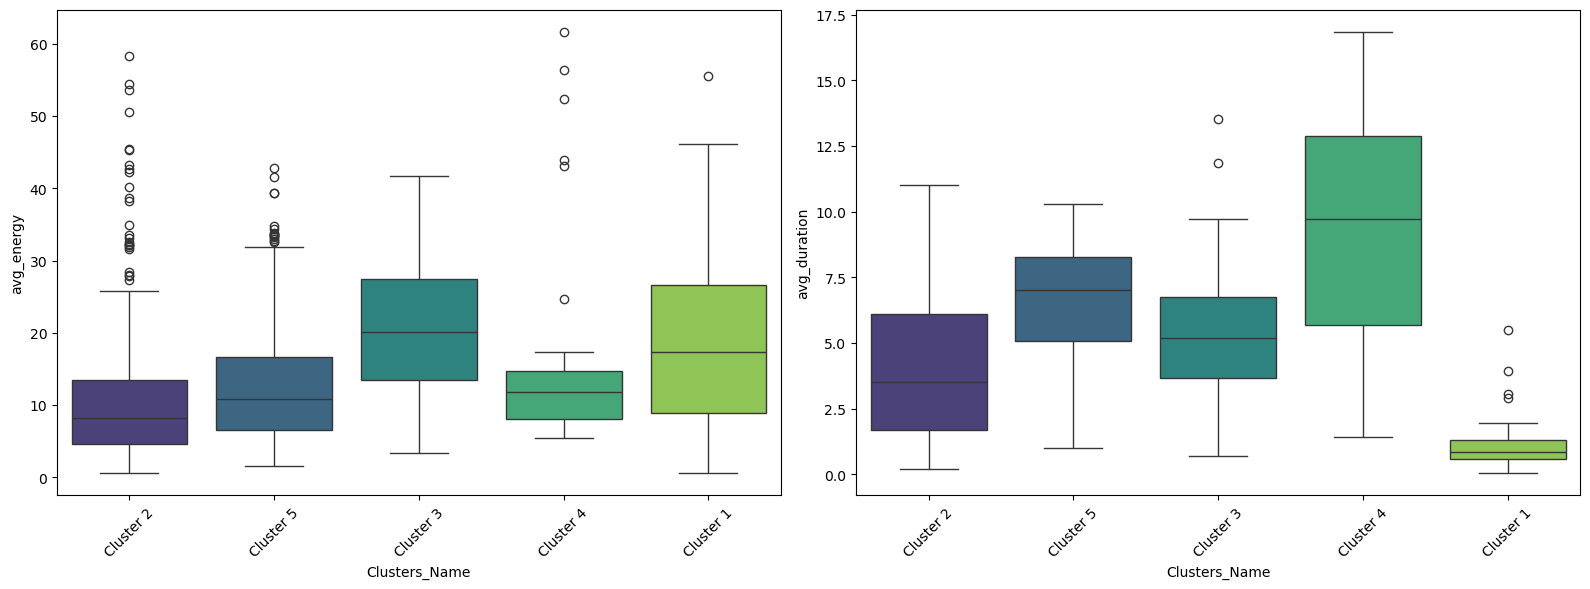

In [511]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(x='Clusters_Name', y='avg_energy', data=user_profiles, 
            ax=axes[0], palette='viridis', hue='Clusters_Name', legend=False)

sns.boxplot(x='Clusters_Name', y='avg_duration', data=user_profiles, 
            ax=axes[1], palette='viridis', hue='Clusters_Name', legend=False)

axes[0].tick_params(axis='x', labelrotation=45)

axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

Our analysis identified four distinct user archetypes: **Low-Volume Short-Stay Users**, **Low-Volume Long-Stay Users**, **High-Volume Long-Stay Users**, and **High-Volume Short-Stay Users**. These categories allow us to add value by maximizing throughput and increasing profitability. By identifying **Low-Volume Long-Stay** users, who occupy a space while drawing very little energy, operators can implement fees or time limits to encourage turnover. This ensures spots remain available for our most profitable segment, the **High-Volume Short-Stay** Users. Because these users maximize both revenue and throughput, they are also ideal targets for marketing campaigns, such as discount cards.

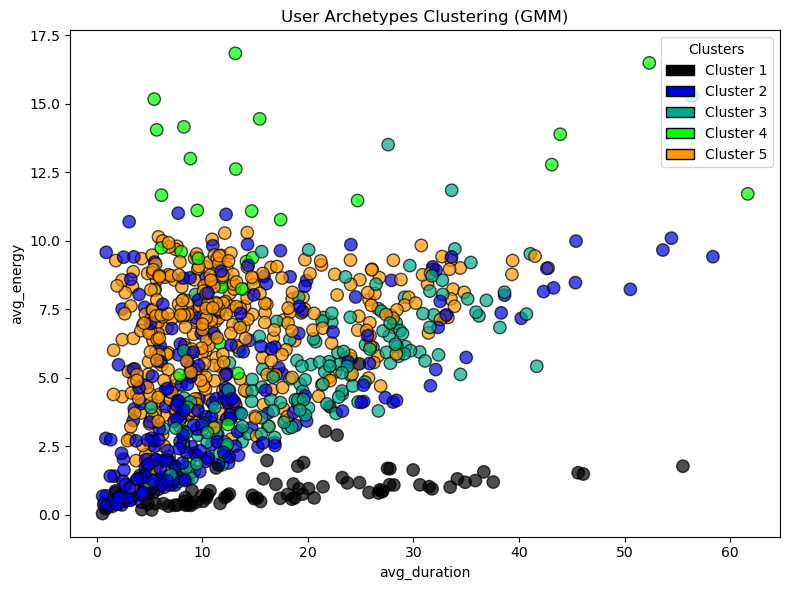

In [512]:
n_clusters = user_profiles['Clusters_Name'].nunique()
X = user_profiles[['avg_energy', 'avg_duration']].values
cluster_labels = user_profiles['Clusters'].values

plt.figure(figsize=(8, 6))

colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

plt.scatter(
    X[:, 0], 
    X[:, 1], 
    c=colors, 
    s=80, 
    edgecolor='k', 
    alpha=0.7
)
plt.xlabel('avg_duration')
plt.ylabel('avg_energy')
plt.title('User Archetypes Clustering (GMM)')

# Create legend manually using actual cluster names
from matplotlib.patches import Patch
unique_clusters = sorted(user_profiles['Clusters'].unique())
legend_elements = [Patch(facecolor=cm.nipy_spectral(i / n_clusters), 
                         edgecolor='k', label=user_profiles[user_profiles['Clusters'] == i]['Clusters_Name'].iloc[0])
                   for i in unique_clusters]
plt.legend(handles=legend_elements, title='Clusters', loc='best')
plt.tight_layout()
plt.show()



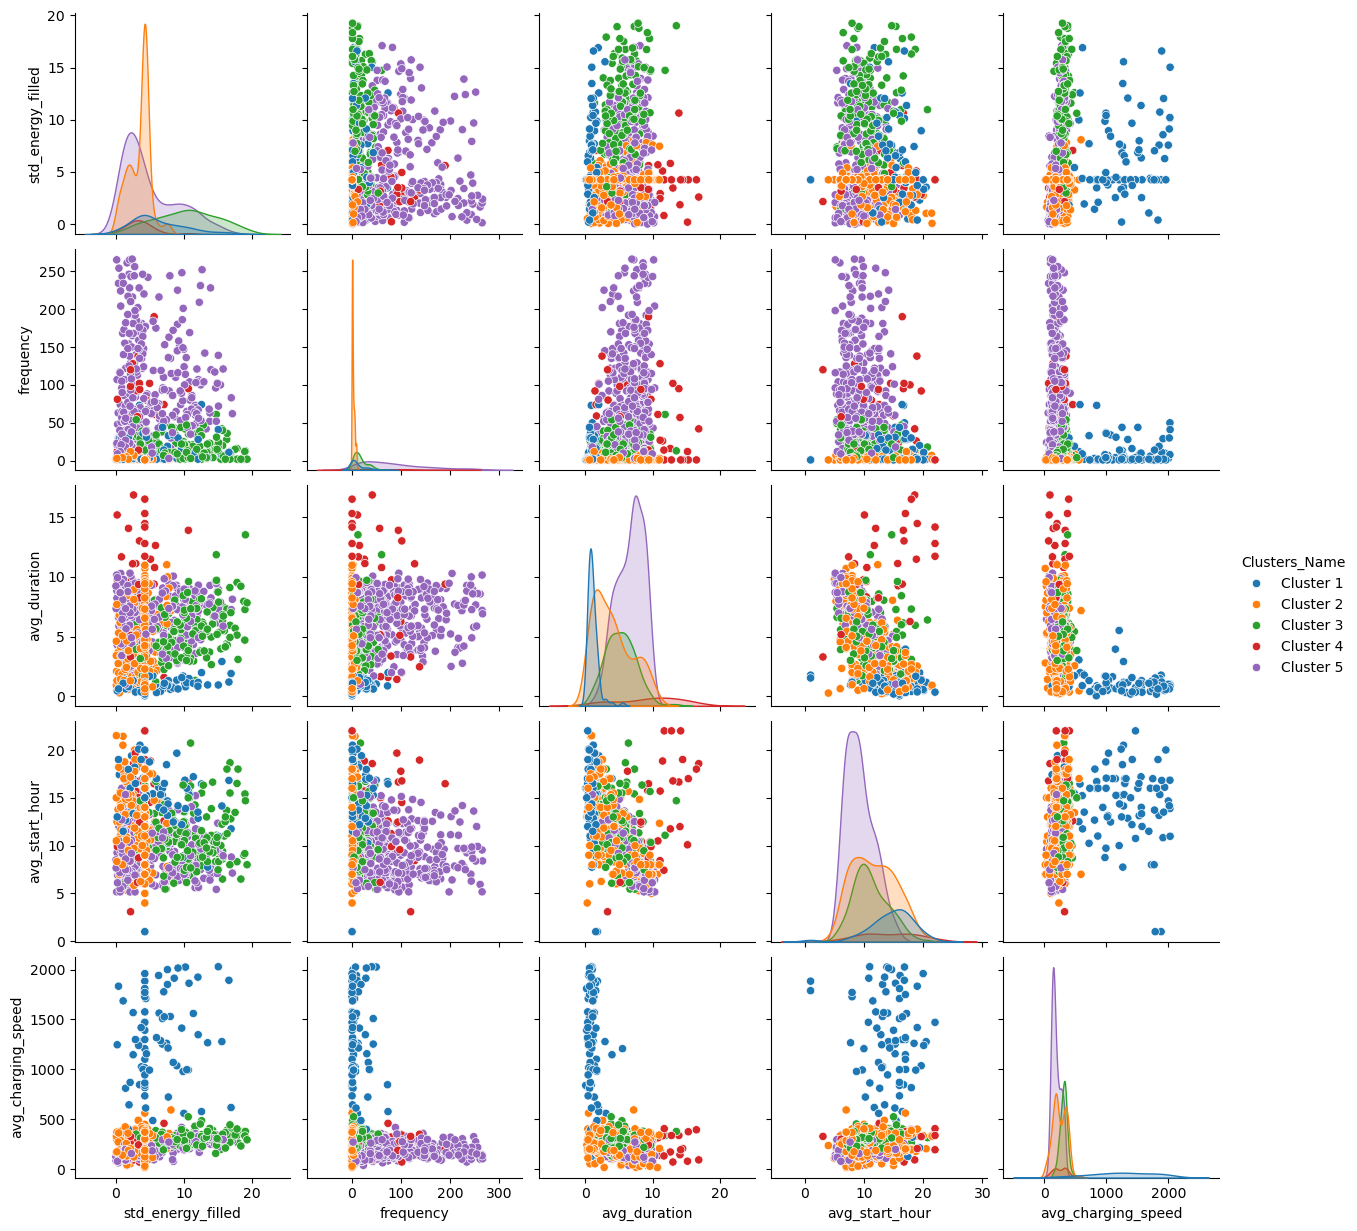

In [513]:
example_features = features_to_standardize

hue_order = sorted(user_profiles['Clusters_Name'].unique())
sns.pairplot(
    user_profiles[example_features + ['Clusters_Name']], 
    diag_kind='kde', 
    hue='Clusters_Name', 
    hue_order=hue_order,
    
)
plt.show()

**maybe noch bezüglich weekend session schauen sonst unnötiges feature**

* Cluster 1: Loyal everyday users
  * charge frequently with a medium energy delivered per session
  * fairly consistent charged energy due to medium std_energy
  * mostly use site 1, meaning they are highly site loyal
  * typical start hours & medium avg_charging_speed are in line with typical AC charging at a know location
  * **=> stable regular customers with plannable & predictable charging patterns, ideal for tarifs, loyalty programs & forecasting**

* Cluster 2: Short-range loyal customers
  * comparable frequency to cluster 1 with a little bit less avg_energy, meaning they charge a lot  but in small amount of energy which is typical for commuting (consistent with high pct_site_1 which is the private one)
  * moderate std_energy which suggest at routine usage pattern
  * **=> everyday users with short driving profile, ideal for little Top-up tariff**

* Cluster 3: Light infrequent users
  * lowest avg_duration and avg_energy and low frequency suggesting these users charge one a few occasion and when they do then short and few
  * low avg_minutes available suggests their vehicle is only a short amount of time at the charging site
  * charging_speed also relatively low and also pct_site_1 not extrem, which means they use different locations and also probably AC
  * **=> occasional users for who charging is not important, relevant for Pay-per-use models and not for complex pricing structures or programs**

* Cluster 4: Heavy flexible chargers
  * high avg_energy and avg_kWh_req means these users charge more energy per session (maybe long distance drivers or one with a car with a high consupmtion)
  * high std_energy shows big dips in energy demand (maybe due to variety of driving profiles)
  * high avg_minutes_available show long and flexible charging hours (over night, during work)
  * moderate frequency and pct_site_1, so they don't charge very often and at different locations
  * **=> users with high energy demand and flexibility, ideal for dynamic pricing 

* Cluster 5: New or one-off users
  * single_session = 1 and frequency =  1 meaning they only charged once
  * other key figures in the mean values
  * **=> real one time users, or new users, ideal for Onboarding and activation campaigns**

* Cluster 6: intesive multi-site users
  * high frequency and relatively high avg_energy, means they charge a lot with substantial energy (intensive users)
  * increased avg_minutes_available suggesting longer charging availability
  * middle pct_site_1 means they are not location loyal (comb of private and public users)
  * **=> Frequent users who flexibly use multiple charging points; important for roaming offers, location planning, and load management across the network**

* Cluster 7: fast charging power users
  * quite high avg_charging_speed, typical for DC fast charging
  high avg_energy and avg_minutes_available
  * low pct_site_1 suggests they mostly use the public site
  * **=> highy mobil users with high energy demand and clear preference for fast charging, ideal utilization and Cost-effectiveness of HPC sites**

* Cluster 8: Evening chargers with moderate use
  * high avg_start_hour means they charge in the evening 
  * moderate frequency and avg_energy suggest regularely but not extreme use
  * middle pct_site_1 so we have users form public and private site
  * **=> Classic after-work chargers, suitable for time-controlled, grid-friendly tariffs (e.g., slightly shifted start times to reduce peaks).** 